#### section A

1. Identify the string methods and their execution order needed to remove extra
spaces and fix inconsistent casing in a product name.


Use strip() to remove leading and trailing spaces.
Use split() to separate words and remove extra spaces between them.
Use ' '.join() to join the words with a single space.
Use title() (or lower()/upper() as needed) to make the casing consistent.

Execution Order:
strip() → split() → ' '.join() → title()

2.Explain why manual CSV loading often treats numeric columns as strings and
identify the function used to convert them to floats

When reading a CSV manually, all values are read as strings because files store data as text.
Numeric values must be converted before performing calculations.
Use the float() function to convert string values into floating-point numbers.

3.Determine the best data structure for mapping product names to total sales
and explain the drawback of using a list instead

The best data structure is a dictionary (dict) because it stores data as key-value pairs, where the product name is the key and total sales are the value.
Drawback of a list: Searching for a product requires checking each element one by one, making lookups slower and less efficient.

4.Compare using a manual for loop versus the sum() function, identifying a
scenario where the loop is the only viable option.

sum() is simple, concise, and efficient for adding numeric values in an iterable.
A for loop is more flexible because it allows conditions, filtering, validation, and custom calculations.
Scenario where only a for loop works: Summing only sales greater than ₹1000 or skipping invalid values before adding them.

5. Describe how to implement type checking or error handling to prevent a
TypeError when comparing a potential string variable to a number

Use type checking with isinstance(variable, (int, float)) before comparison.
Alternatively, use try-except to convert the value with float() and handle invalid inputs using except ValueError or except TypeError.
This prevents errors when comparing strings with numbers.

6.Explain the benefits of modularizing a data pipeline into separate functions
and the risks of using a single large code block in analytics

Benefits of modularization:

Improves code readability.
Makes debugging easier.
Allows code reuse.
Simplifies testing and maintenance.
Enhances teamwork and scalability.

Risks of a single large code block:

Difficult to understand and debug.
Hard to maintain or modify.
Increases chances of errors.
Reduces code reusability.
Makes testing individual parts difficult.

### section B

In [3]:
import pandas as pd

In [8]:
df = pd.read_csv(r"C:\Users\Manav\Desktop\sales_data_sample.csv", encoding="cp1252")

In [9]:
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


In [10]:
df["PRODUCTLINE"] = df["PRODUCTLINE"].str.strip().str.title()

In [11]:
print("Cleaned PRODUCTLINE Column:")
print(df["PRODUCTLINE"].head())

Cleaned PRODUCTLINE Column:
0    Motorcycles
1    Motorcycles
2    Motorcycles
3    Motorcycles
4    Motorcycles
Name: PRODUCTLINE, dtype: str


In [12]:
clean_sales = []

for value in df["SALES"]:
    value = str(value)
    cleaned = ""

    for ch in value:
        if ch.isdigit() or ch == ".":
            cleaned += ch

    if cleaned != "":
        clean_sales.append(float(cleaned))
    else:
        clean_sales.append(0.0)

df["SALES"] = clean_sales

print("Cleaned SALES Column:")
print(df["SALES"].head())

Cleaned SALES Column:
0    2871.00
1    2765.90
2    3884.34
3    3746.70
4    5205.27
Name: SALES, dtype: float64


In [13]:
sales_dict = {}

for index, row in df.iterrows():
    product = row["PRODUCTLINE"]
    sales = row["SALES"]

    if product in sales_dict:
        sales_dict[product] += sales
    else:
        sales_dict[product] = sales

print("Total Sales by Product Line:")
print(sales_dict)

Total Sales by Product Line:
{'Motorcycles': 1166388.3400000003, 'Classic Cars': 3919615.659999997, 'Trucks And Buses': 1127789.8399999996, 'Vintage Cars': 1903150.8399999992, 'Planes': 975003.5700000001, 'Ships': 714437.13, 'Trains': 226243.46999999997}


In [14]:
print("Revenue Classification:\n")

for product, total in sales_dict.items():
    if total > 100000:
        print(f"{product}: {total:.2f} --> High Revenue Product")
    else:
        print(f"{product}: {total:.2f} --> Normal Revenue Product")

Revenue Classification:

Motorcycles: 1166388.34 --> High Revenue Product
Classic Cars: 3919615.66 --> High Revenue Product
Trucks And Buses: 1127789.84 --> High Revenue Product
Vintage Cars: 1903150.84 --> High Revenue Product
Planes: 975003.57 --> High Revenue Product
Ships: 714437.13 --> High Revenue Product
Trains: 226243.47 --> High Revenue Product


### section C

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv(r"C:\Users\Manav\Desktop\sales_data_sample.csv", encoding="cp1252")

In [18]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   str    
 6   STATUS            2823 non-null   str    
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   str    
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   str    
 13  CUSTOMERNAME      2823 non-null   str    
 14  PHONE             2823 non-null   str    
 15  ADDRESSLINE1      2823 non-null   str    
 16  ADDRESSLINE2      302 non-null    str    
 17  CITY  

In [20]:
df.shape

(2823, 25)

In [21]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='str')

In [22]:
df.dtypes

ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE               str
STATUS                  str
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE             str
MSRP                  int64
PRODUCTCODE             str
CUSTOMERNAME            str
PHONE                   str
ADDRESSLINE1            str
ADDRESSLINE2            str
CITY                    str
STATE                   str
POSTALCODE              str
COUNTRY                 str
TERRITORY               str
CONTACTLASTNAME         str
CONTACTFIRSTNAME        str
DEALSIZE                str
dtype: object

In [23]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


In [25]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

In [28]:
df["CalculatedSales"] = (
    df["QUANTITYORDERED"] *
    df["PRICEEACH"]
)

In [29]:
df["Difference"] = (
    df["CalculatedSales"] -
    df["SALES"]
)

In [30]:
df["RevenueError"] = (
    abs(df["Difference"]) > 1
)

In [31]:
df[df["QUANTITYORDERED"] < 0]

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,CalculatedSales,Difference,RevenueError


In [32]:
df[
df["ORDERDATE"] >
pd.Timestamp.today()
]

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,CalculatedSales,Difference,RevenueError


In [33]:
Q1 = df["SALES"].quantile(0.25)

In [34]:
Q3 = df["SALES"].quantile(0.75)

In [35]:
IQR = Q3 - Q1

In [36]:
lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

In [37]:
outliers = df[
(df["SALES"] < lower) |
(df["SALES"] > upper)
]

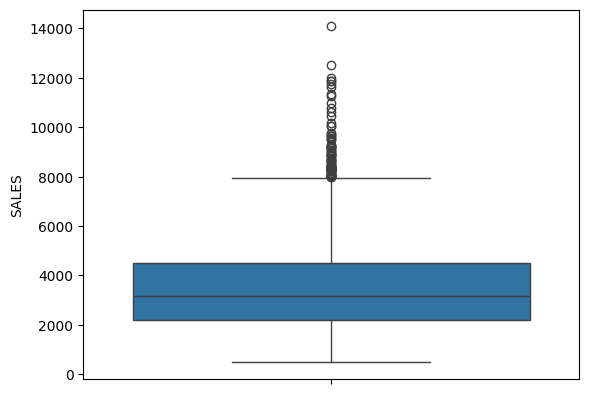

In [38]:
sns.boxplot(df["SALES"])
plt.show()

<Axes: xlabel='SALES', ylabel='Count'>

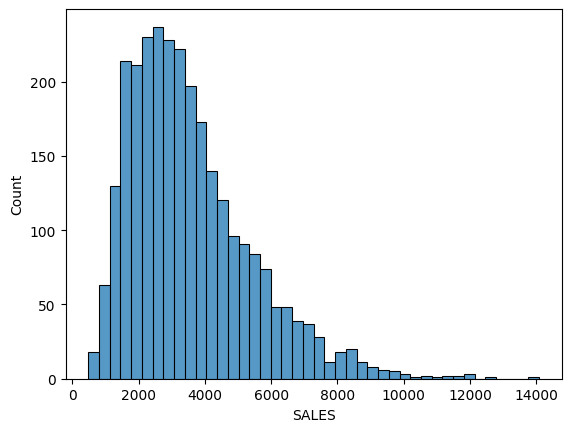

In [39]:
sns.histplot(df["SALES"])

<Axes: xlabel='PRODUCTLINE', ylabel='SALES'>

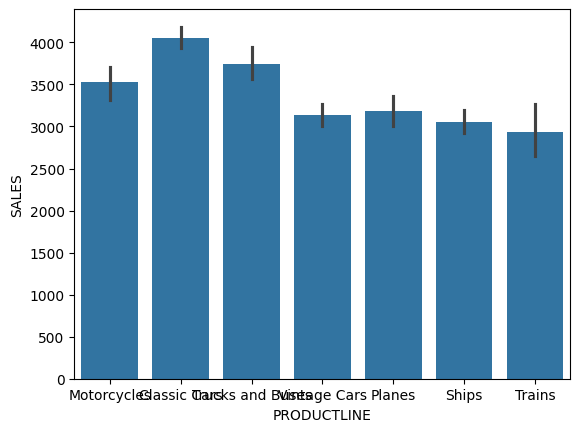

In [40]:
sns.barplot(
x="PRODUCTLINE",
y="SALES",
data=df
)

<Axes: xlabel='ORDERDATE'>

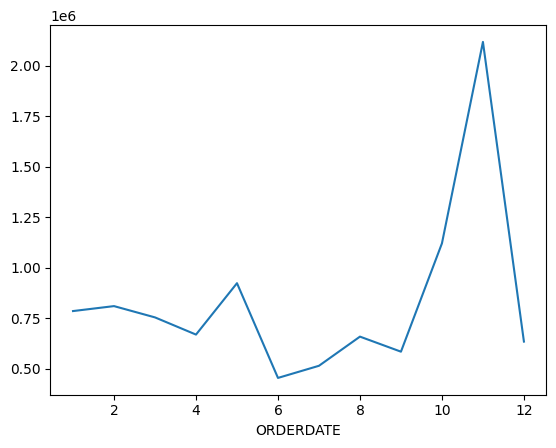

In [41]:
df.groupby(
df["ORDERDATE"].dt.month
)["SALES"].sum().plot()